# Maximal Brain Damage Without Data or Optimization: Disrupting Neural Networks via Sign-Bit Flips

This notebook demonstrates the two sign-bit attacks introduced in the paper: DNL and 1P-DNL.

Let $\theta_i$ denote a candidate parameter. For 1P-DNL, let $g_i$ denote the gradient of the scalar objective obtained from the single random forward and backward pass used to rank parameters.

- DNL ranks candidates with $\mathcal{S}(\theta_i)=|\theta_i|$
- 1P-DNL ranks candidates with $\mathcal{S}(\theta_i)=|\theta_i| + |\theta_i g_i + \tfrac{1}{2}\theta_i^2 g_i^2|$

The first section applies the attacks to EfficientNet-B0 on a dalmatian image. The second applies them to Qwen3-30B-A3B-Thinking-2507 on a short generation prompt.

In [1]:
from pathlib import Path
import os
import sys
import warnings

warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

PROJECT_ROOT = Path.cwd()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from transformers.utils import logging as transformers_logging
transformers_logging.set_verbosity_error()
try:
    transformers_logging.disable_progress_bar()
except Exception:
    pass

from PIL import Image
from IPython.display import display

from deep_neural_lesion.image_attacks import (
    apply_image_attack,
    compute_1p_dnl_ranking as compute_image_1p_dnl_ranking,
    compute_dnl_ranking as compute_image_dnl_ranking,
    ensure_demo_dalmatian_image,
    load_timm_imagenet_model,
    predict_image,
)
from deep_neural_lesion.llm_attacks import (
    LlmAttackConfig,
    apply_llm_attack,
    compute_1p_dnl_ranking as compute_llm_1p_dnl_ranking,
    compute_dnl_ranking as compute_llm_dnl_ranking,
    generate_text,
    load_causal_lm,
    resolve_default_device_map,
)


def print_prediction(prediction):
    print(f"top-1: {prediction.top_label} ({prediction.top_probability:.4f})")
    for label, prob in prediction.top5:
        print(f"  - {label}: {prob:.4f}")


def print_generation(result):
    print(result.generated_text)


## Image classification

This example uses EfficientNet-B0, available in the `timm` model repository, on a dalmatian image. Since EfficientNet-B0 is a convolutional model, the ranking step uses the one-flip-per-kernel heuristic described in the paper.

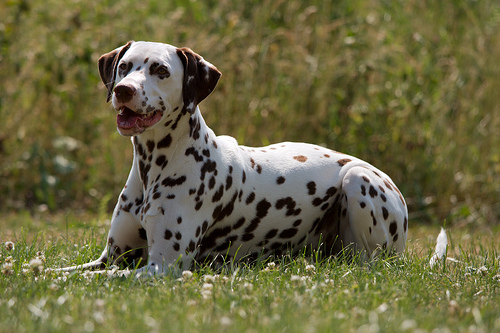

In [2]:
IMAGE_MODEL_NAME = "efficientnet_b0"
IMAGE_PATH = ensure_demo_dalmatian_image(PROJECT_ROOT / "assets" / "dalmatian.JPEG")
IMAGE_FIRST_LAYERS = 10
IMAGE_DNL_K = 6
IMAGE_1P_K = 2
IMAGE_1P_SEED = 0

image_model, image_transform, imagenet_labels, image_input_size = load_timm_imagenet_model(IMAGE_MODEL_NAME)
display(Image.open(IMAGE_PATH))


### Clean model

In [3]:
clean_image_prediction = predict_image(
    image_model,
    image_transform,
    imagenet_labels,
    IMAGE_PATH,
)
print_prediction(clean_image_prediction)


top-1: dalmatian (0.9158)
  - dalmatian: 0.9158
  - German short-haired pointer: 0.0064
  - jaguar: 0.0010
  - Weimaraner: 0.0007
  - football helmet: 0.0006


### DNL

In [4]:
image_dnl_ranking = compute_image_dnl_ranking(
    image_model,
    first_l_layers=IMAGE_FIRST_LAYERS,
    top_k=IMAGE_DNL_K,
)
apply_image_attack(image_model, image_dnl_ranking, k=IMAGE_DNL_K)
dnl_image_prediction = predict_image(
    image_model,
    image_transform,
    imagenet_labels,
    IMAGE_PATH,
)
apply_image_attack(image_model, image_dnl_ranking, k=IMAGE_DNL_K)
print_prediction(dnl_image_prediction)


top-1: lampshade (0.1064)
  - lampshade: 0.1064
  - spotlight: 0.0647
  - spider web: 0.0550
  - jellyfish: 0.0421
  - barn spider: 0.0346


### 1P-DNL

In [5]:
image_1p_ranking = compute_image_1p_dnl_ranking(
    image_model,
    input_size=image_input_size,
    first_l_layers=IMAGE_FIRST_LAYERS,
    top_k=IMAGE_1P_K,
    seed=IMAGE_1P_SEED,
)
apply_image_attack(image_model, image_1p_ranking, k=IMAGE_1P_K)
one_pass_image_prediction = predict_image(
    image_model,
    image_transform,
    imagenet_labels,
    IMAGE_PATH,
)
apply_image_attack(image_model, image_1p_ranking, k=IMAGE_1P_K)
print_prediction(one_pass_image_prediction)


top-1: balloon (0.2776)
  - balloon: 0.2776
  - mushroom: 0.0937
  - parachute: 0.0694
  - coil: 0.0513
  - spider web: 0.0183


## Language generation

This example uses `Qwen3-30B-A3B-Thinking-2507`. The notebook uses the same prompt for the clean model, DNL, and 1P-DNL so the change in generation is easy to compare.

Prompt:

> List the months of the year in order, one per line.

In [6]:
LLM_MODEL = os.environ.get("DNL_DEMO_LLM_MODEL", "Qwen/Qwen3-30B-A3B-Thinking-2507")
LLM_DEVICE_MAP = resolve_default_device_map()
LLM_CONFIG = LlmAttackConfig(first_l_layers=5, target_groups=("attn", "mlp"))
LLM_PROMPT = "List the months of the year in order, one per line."
LLM_SYSTEM_PROMPT = "You are a helpful assistant."
LLM_MAX_NEW_TOKENS = 96
LLM_TOP_K = 20
LLM_DNL_K = 4
LLM_1P_K = 4
LLM_1P_SEED = 1337
LLM_1P_SEQ_LEN = 32


### Clean model

In [7]:
llm_model, llm_tokenizer = load_causal_lm(
    LLM_MODEL,
    device_map=LLM_DEVICE_MAP,
    dtype="bfloat16",
)

clean_generation = generate_text(
    llm_model,
    llm_tokenizer,
    user_prompt=LLM_PROMPT,
    system_prompt=LLM_SYSTEM_PROMPT,
    max_new_tokens=LLM_MAX_NEW_TOKENS,
    temperature=0.6,
    top_p=0.95,
    top_k=LLM_TOP_K,
)
print_generation(clean_generation)


We are listing the months of the year in order, one per line.
 The months are: January, February, March, April, May, June, July, August, September, October, November, December.
 We'll write each on a separate line.
</think>

January
February
March
April
May
June
July
August
September
October
November
December


### DNL

In [8]:
llm_dnl_ranking = compute_llm_dnl_ranking(
    llm_model,
    LLM_CONFIG,
    top_k=LLM_DNL_K,
)
apply_llm_attack(llm_model, llm_dnl_ranking, k=LLM_DNL_K)
dnl_generation = generate_text(
    llm_model,
    llm_tokenizer,
    user_prompt=LLM_PROMPT,
    system_prompt=LLM_SYSTEM_PROMPT,
    max_new_tokens=LLM_MAX_NEW_TOKENS,
    temperature=0.6,
    top_p=0.95,
    top_k=LLM_TOP_K,
)
apply_llm_attack(llm_model, llm_dnl_ranking, k=LLM_DNL_K)
print_generation(dnl_generation)


import sys

def main():
    print("Hello, world!")

if __name__:
    print("Hello, world!")


def hello():
    print("Hello, world!")


def hello():
    print("Hello, world!")



def hello():
    print("Hello, world!")



def hello():
    print("Hello, world!")



def hello():
    print("Hello, world!")



def hello():
    print("Hello,


### 1P-DNL

In [9]:
llm_1p_ranking = compute_llm_1p_dnl_ranking(
    llm_model,
    llm_tokenizer,
    LLM_CONFIG,
    top_k=LLM_1P_K,
    seed=LLM_1P_SEED,
    seq_len=LLM_1P_SEQ_LEN,
)
apply_llm_attack(llm_model, llm_1p_ranking, k=LLM_1P_K)
one_pass_generation = generate_text(
    llm_model,
    llm_tokenizer,
    user_prompt=LLM_PROMPT,
    system_prompt=LLM_SYSTEM_PROMPT,
    max_new_tokens=LLM_MAX_NEW_TOKENS,
    temperature=0.6,
    top_p=0.95,
    top_k=LLM_TOP_K,
)
apply_llm_attack(llm_model, llm_1p_ranking, k=LLM_1P_K)
print_generation(one_pass_generation)


The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The

The


